In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../outputs/customer_master.csv")
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(5000, 38)


,customer_id,occupation,income,age,residency,customer_type,risk_category,account_count,income_tier_fixed,income_tier_percentile,...,spend_utilities,total_category_spend,pct_spend_e-commerce,pct_spend_electronics,pct_spend_fuel,pct_spend_grocery,pct_spend_pharmacy,pct_spend_restaurants,pct_spend_retail,pct_spend_utilities
0,BUS100000,Business Owner,93112.0,43.0,Resident,Individual,Medium,1,Mass Affluent,Q3,...,30061.46,456115.61,0.051381,0.507296,0.027822,0.247323,0.012612,0.025962,0.061697,0.065908
1,BUS100001,Self-Employed,26956.0,56.0,Resident,Corporate,Medium,1,Mass,Q1 - Bottom 25%,...,19642.57,265514.54,0.116314,0.309326,0.060490,0.319327,0.023545,0.050599,0.046420,0.073979
2,BUS100002,Business Owner,365706.0,39.0,Resident,Joint,Low,1,HNI,Q4 - Top 25%,...,39174.67,573610.52,0.105535,0.358072,0.029959,0.266050,0.031398,0.035450,0.105241,0.068295
3,BUS100003,Self-Employed,21703.0,38.0,Non-Resident,Joint,Low,2,Mass,Q1 - Bottom 25%,...,23791.39,277918.30,0.114795,0.312365,0.050770,0.337192,0.011186,0.029946,0.058140,0.085606
4,BUS100004,Self-Employed,184794.0,64.0,Non-Resident,Corporate,High,1,Affluent,Q4 - Top 25%,...,51022.08,632765.33,0.192627,0.289574,0.010789,0.287150,0.036606,0.050158,0.052462,0.080633


/var/folders/vs/9_md2bzn1kx9mq02dlp60wc80000gn/T/ipykernel_20807/3996790308.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/varunv/Desktop/Alpha Capital Bank/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


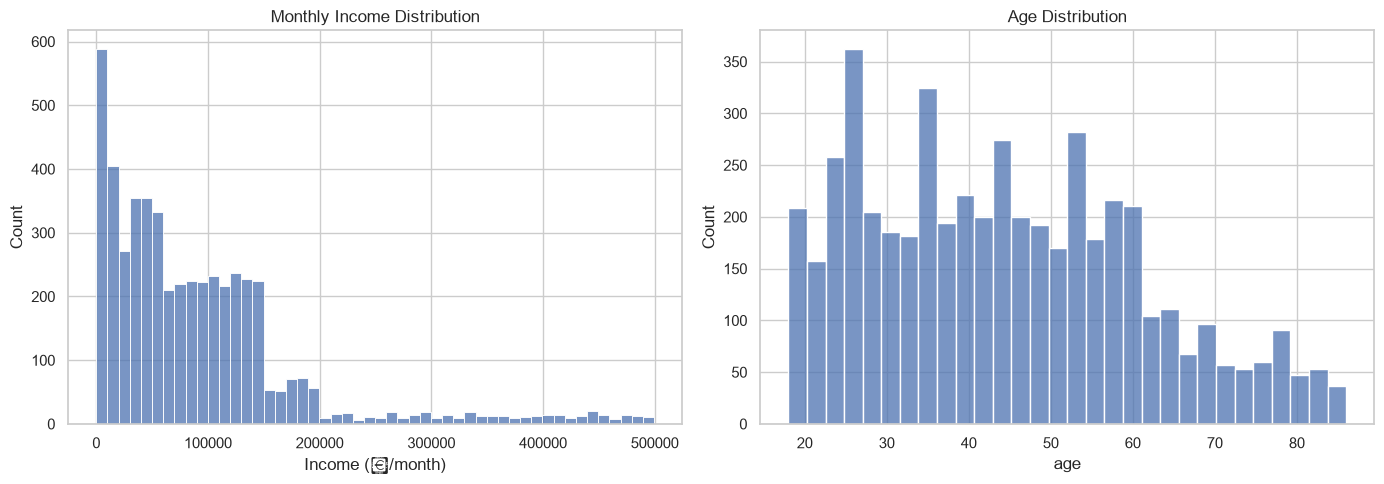

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["income"], bins=50, ax=axes[0])
axes[0].set_title("Monthly Income Distribution")
axes[0].set_xlabel("Income (₹/month)")

sns.histplot(df["age"], bins=30, ax=axes[1])
axes[1].set_title("Age Distribution")

plt.tight_layout()
plt.show()

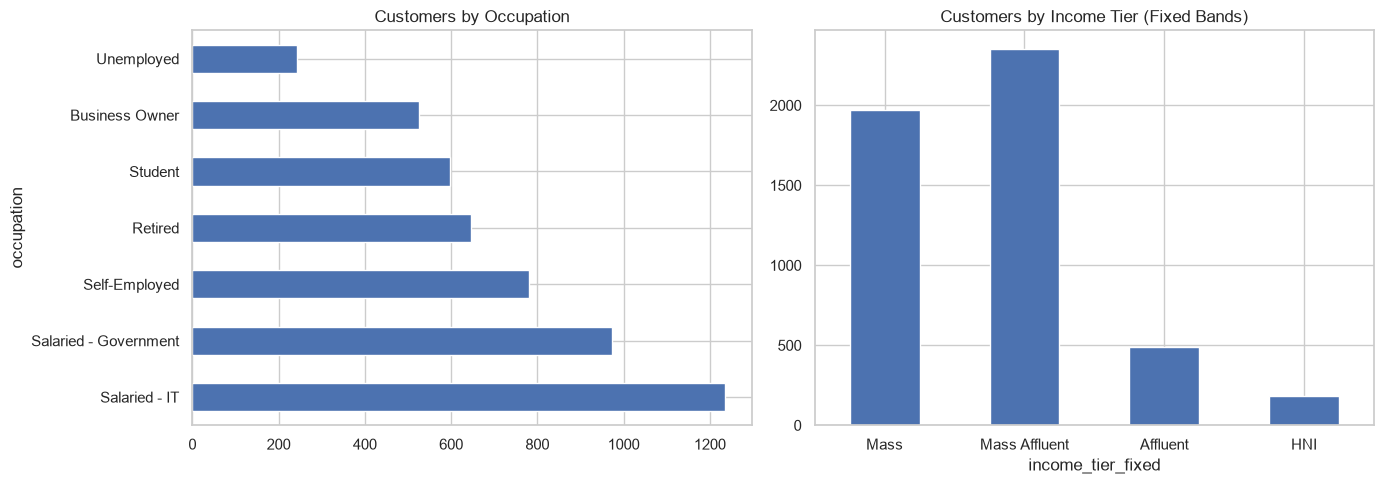

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["occupation"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("Customers by Occupation")

income_tier_order = ["Mass", "Mass Affluent", "Affluent", "HNI"]
df["income_tier_fixed"].value_counts().reindex(income_tier_order).plot(kind="bar", ax=axes[1])
axes[1].set_title("Customers by Income Tier (Fixed Bands)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

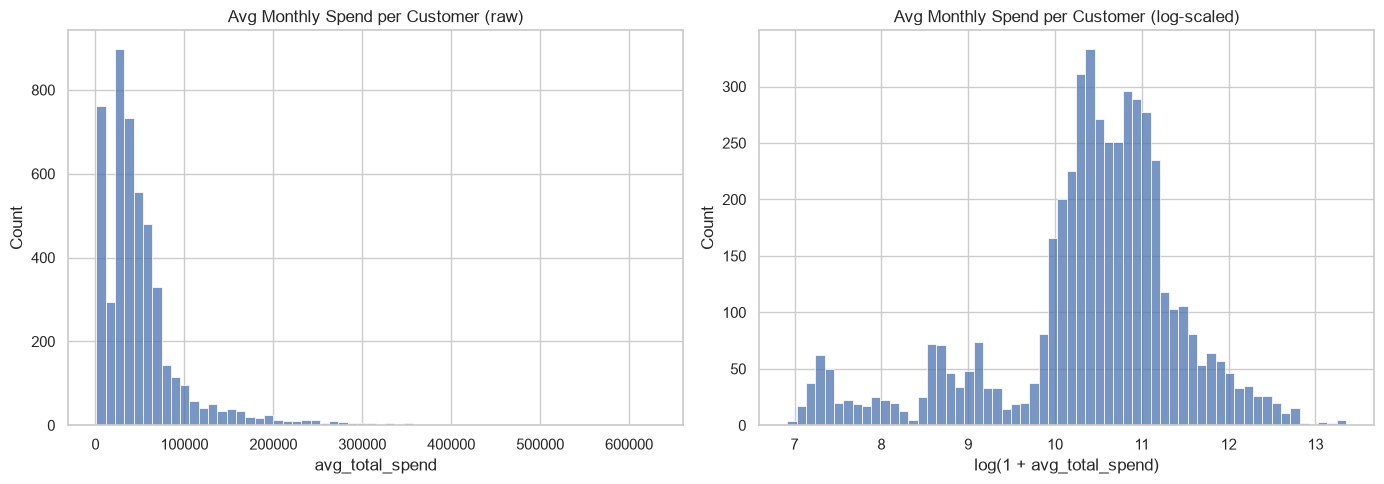

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["avg_total_spend"].dropna(), bins=60, ax=axes[0])
axes[0].set_title("Avg Monthly Spend per Customer (raw)")

sns.histplot(np.log1p(df["avg_total_spend"].dropna()), bins=60, ax=axes[1])
axes[1].set_title("Avg Monthly Spend per Customer (log-scaled)")
axes[1].set_xlabel("log(1 + avg_total_spend)")

plt.tight_layout()
plt.show()

/Users/varunv/Desktop/Alpha Capital Bank/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


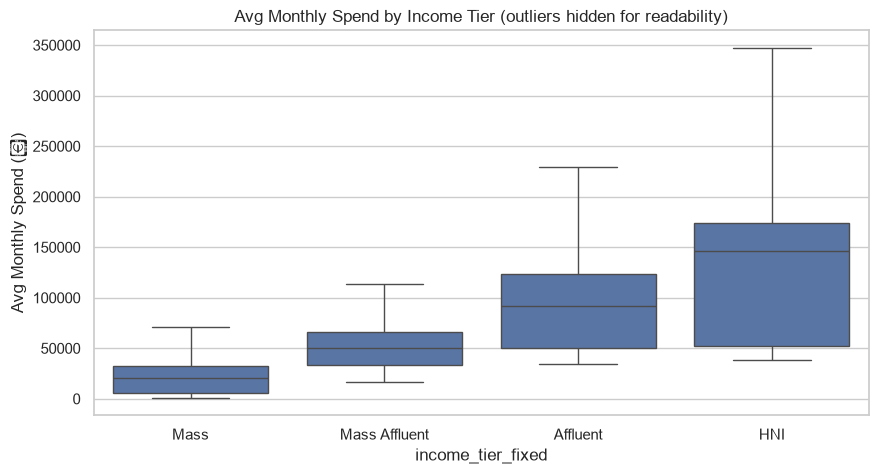

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="income_tier_fixed", y="avg_total_spend", order=income_tier_order, showfliers=False)
plt.title("Avg Monthly Spend by Income Tier (outliers hidden for readability)")
plt.ylabel("Avg Monthly Spend (₹)")
plt.show()

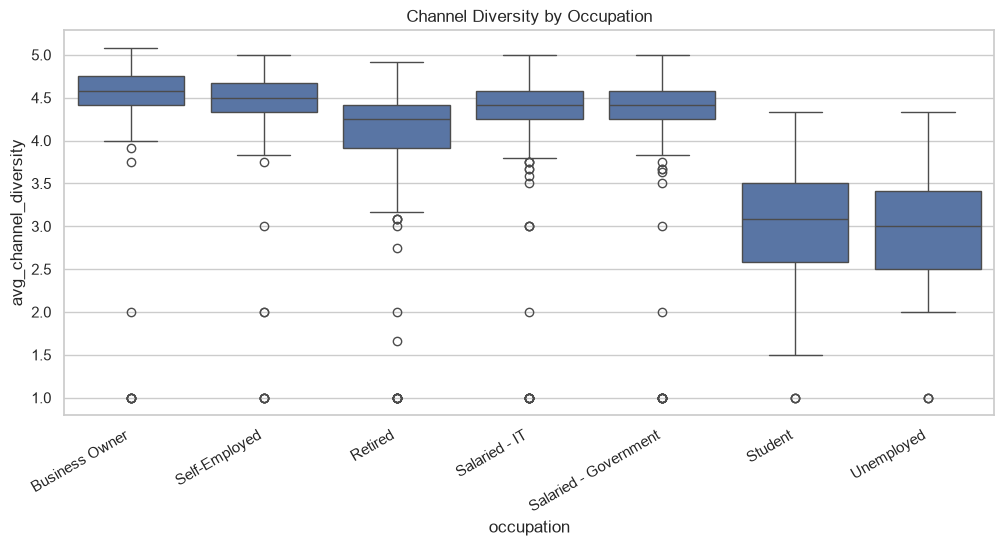

In [6]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="occupation", y="avg_channel_diversity")
plt.title("Channel Diversity by Occupation")
plt.xticks(rotation=30, ha="right")
plt.show()

/Users/varunv/Desktop/Alpha Capital Bank/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


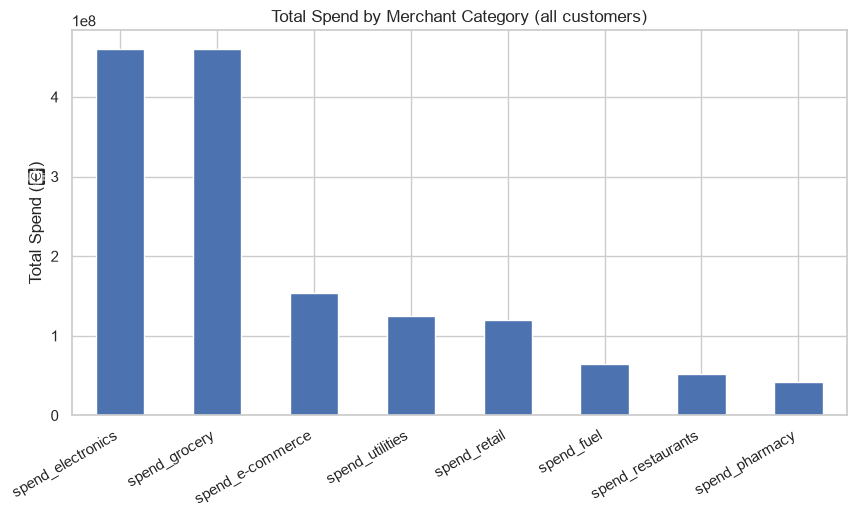

In [7]:
category_cols = [c for c in df.columns if c.startswith("spend_") and c != "spend_"]
category_totals = df[category_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_totals.plot(kind="bar")
plt.title("Total Spend by Merchant Category (all customers)")
plt.ylabel("Total Spend (₹)")
plt.xticks(rotation=30, ha="right")
plt.show()

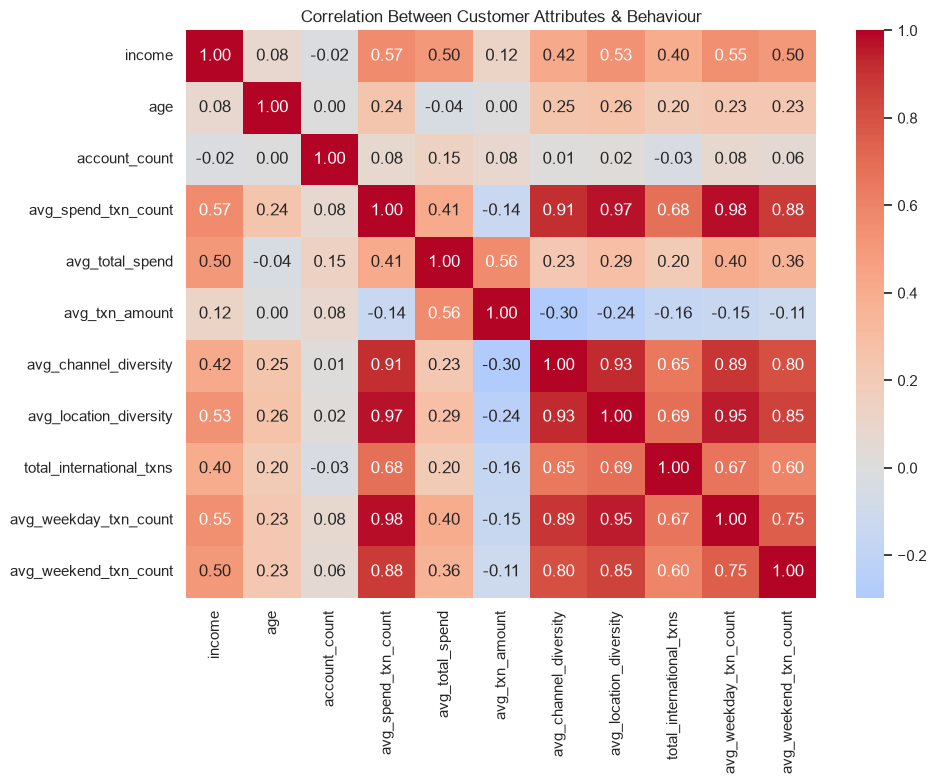

In [8]:
numeric_cols = [
    "income", "age", "account_count",
    "avg_spend_txn_count", "avg_total_spend", "avg_txn_amount",
    "avg_channel_diversity", "avg_location_diversity",
    "total_international_txns", "avg_weekday_txn_count", "avg_weekend_txn_count",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Customer Attributes & Behaviour")
plt.tight_layout()
plt.show()